# 23 — Conformal Prediction Intervals
## Layer 1: From Point Estimates to Calibrated Ranges

**Method:** MAPIE (Model Agnostic Prediction Interval Estimator) wraps our v4.2 XGBoost model to produce statistically valid prediction intervals without retraining.

**Output:**
- 80% prediction interval (covers 80% of true rents)
- 50% prediction interval (most likely range)
- Saved as `models/mapie_regressor_v4.joblib` for backend deployment

In [2]:
import sys, json, re, warnings, hashlib
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score
import xgboost as xgb
from mapie.regression import CrossConformalRegressor
import joblib
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
MODEL_DIR = PROJECT_ROOT / 'models'

# Load the exact same training data and feature prep as notebook 20
units = pd.read_parquet(PROC_DIR / 'units.parquet')
listings = pd.read_parquet(PROC_DIR / 'listings.parquet')
spatial = pd.read_parquet(PROC_DIR / 'spatial_unit.parquet')
gemini = pd.read_parquet(PROC_DIR / 'gemini_image_features.parquet')

df = units.merge(listings[['unit_id', 'rent_sqm', 'baseRent', 'totalRent', 'serviceCharge']], on='unit_id')
df = df.merge(spatial.drop(columns=['coord_source']), on='unit_id', how='left')
df = df.merge(gemini, on='unit_id', how='left', suffixes=('', '_img'))

print(f'Loaded: {len(df):,} rows')

# Load the trained v4.2 model
model = joblib.load(MODEL_DIR / 'xgboost_rent_v4.joblib')
encoder = joblib.load(MODEL_DIR / 'feature_encoder_v4.joblib')
with open(MODEL_DIR / 'model_config.json') as f:
    config = json.load(f)

print(f'Model: {config["model_version"]}, {len(config["features"])} features')

Loaded: 8,256 rows
Model: v4.2.0, 75 features


In [3]:
# Reproduce exact feature prep from notebook 20
RAW_FILE = RAW_DIR / 'scraping' / 'dataset_immobilienscout24-scraper_2026-03-18_23-03-51-178.json'
with open(RAW_FILE, encoding='utf-8') as f:
    raw = json.load(f)
raw_lookup = {str(r.get('adTargetingParameters', {}).get('obj_scoutId', '')): r for r in raw}

from data.pipelines.ingestion import year_to_building_era

# NLP features
def extract_title_features(scout_id):
    rec = raw_lookup.get(scout_id)
    if not rec: return {}
    title = rec.get('basicInfo', {}).get('title', '').lower()
    atp = rec.get('adTargetingParameters', {})
    return {
        'is_altbau': int('altbau' in title), 'is_neubau': int('neubau' in title or 'erstbezug' in title),
        'is_furnished': int('möbliert' in title or 'furnished' in title),
        'is_tauschwohnung': int('tausch' in title), 'is_renovated': int('saniert' in title or 'renoviert' in title),
        'is_wg': int('wg' in title), 'is_befristet': int('befristet' in title or 'zwischenmiete' in title),
        'has_terrasse': int('terrasse' in title), 'is_dachgeschoss': int('dachgeschoss' in title),
        'picturecount': int(atp.get('obj_picturecount', 0) or 0),
    }

title_df = pd.DataFrame([extract_title_features(sid) for sid in df['scout_id']])
title_df.index = df.index
for col in title_df.columns:
    df[col] = title_df[col]

df['nebenkosten_sqm'] = df['serviceCharge'] / df['livingSpace'].replace(0, np.nan)

# HeatingGroup
HEATING_GROUPS = {'gas': ['gas'], 'district': ['district_heating'], 'oil': ['oil'],
    'electric': ['electric', 'electricity'], 'heat_pump': ['heat_pump', 'geothermal', 'environmental_thermal_energy'],
    'central': ['central_heating', 'self_contained_central_heating'], 'floor': ['floor_heating'],
    'combined': ['combined_heat_and_power']}
def group_heating(ht):
    for g, kws in HEATING_GROUPS.items():
        for kw in kws:
            if kw in str(ht).lower(): return g
    return 'unknown'
df['heatingGroup'] = df['heatingType'].apply(group_heating)

def size_category(sqm):
    if sqm < 30: return 'micro'
    if sqm < 50: return 'small'
    if sqm < 70: return 'medium'
    if sqm < 100: return 'large'
    return 'xlarge'
df['sizeCategory'] = df['livingSpace'].apply(size_category)

# Missing data fixes
mask = df['yearConstructed'].isna()
def infer_year(sid):
    rec = raw_lookup.get(sid)
    if not rec: return None
    t = rec.get('basicInfo', {}).get('title', '').lower()
    if 'erstbezug' in t or 'neubau' in t: return 2024
    if 'altbau' in t: return 1905
    m = re.search(r'(19|20)\d{2}', t)
    if m:
        y = int(m.group())
        if 1850 <= y <= 2027: return y
    return None
df.loc[mask, 'yearConstructed'] = df.loc[mask, 'scout_id'].apply(infer_year)

thermal_by_heat = df.groupby('heatingType')['thermalChar'].median()
for ht, med in thermal_by_heat.items():
    if pd.notna(med):
        m = (df['thermalChar'].isna()) & (df['heatingType'] == ht)
        df.loc[m, 'thermalChar'] = med

for ft, fv in {'ground_floor': 0, 'raised_ground_floor': 0, 'half_basement': -1, 'penthouse': 8}.items():
    m = (df['floor'].isna()) & (df['typeOfFlat'] == ft)
    df.loc[m, 'floor'] = fv

df['building_era'] = df['yearConstructed'].apply(year_to_building_era)

# Build feature matrix (same as notebook 20)
ALL_FEATURES = config['features']
feature_groups = config['feature_groups']

for col in feature_groups['numeric']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median() if col in df.columns else 0)
for col in feature_groups['binary']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
for col in feature_groups['spatial']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
for col in feature_groups['categorical']:
    df[col] = df[col].fillna('unknown').astype(str).str.lower().str.strip()

df[feature_groups['categorical']] = encoder.transform(df[feature_groups['categorical']])

X = df[ALL_FEATURES].copy()
y = df['rent_sqm'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Feature matrix: {X.shape}')
print(f'Train: {len(X_train):,}, Test: {len(X_test):,}')

Feature matrix: (8256, 75)
Train: 6,604, Test: 1,652


## Fit MAPIE Conformal Prediction on Training Data

MAPIE wraps the existing XGBoost model — no retraining. It uses cross-validation residuals to calibrate prediction intervals.

In [4]:
# Create clean estimator without early_stopping
best_params = config['best_params'].copy()
n_trees = best_params.pop('n_estimators')

clean_model = xgb.XGBRegressor(
    **best_params, n_estimators=n_trees, random_state=42, n_jobs=-1,
)
print(f'Clean estimator: {n_trees} trees')

# Fit MAPIE at multiple confidence levels
print('\nFitting MAPIE cross-conformal predictor (5-fold CV)...')

intervals = {}  # conf → (lower, upper) arrays
for conf in [0.5, 0.8, 0.9]:
    print(f'  Fitting {int(conf*100)}% interval...', end=' ', flush=True)
    ccr = CrossConformalRegressor(
        estimator=clean_model, confidence_level=conf, method="plus", cv=5, n_jobs=-1,
    )
    ccr.fit_conformalize(X_train.values, y_train.values)
    preds, pi_raw = ccr.predict_interval(X_test.values)
    # pi_raw shape is (n, 2, 1) — squeeze last dim
    pi = pi_raw[:, :, 0]  # now (n, 2): column 0=lower, column 1=upper
    intervals[conf] = pi
    print('done.')

# Keep the 80% fitted model for saving
mapie_80 = CrossConformalRegressor(
    estimator=clean_model, confidence_level=0.8, method="plus", cv=5, n_jobs=-1,
)
mapie_80.fit_conformalize(X_train.values, y_train.values)

# Point predictions from original model
y_pred = model.predict(X_test.values)

print(f'\nTest set: {len(y_pred):,} predictions')
print(f'R² (point estimate): {r2_score(y_test, y_pred):.4f}')

# Empirical coverage check
for conf, pi in intervals.items():
    lower, upper = pi[:, 0], pi[:, 1]
    coverage = np.mean((y_test.values >= lower) & (y_test.values <= upper))
    avg_width = np.mean(upper - lower)
    target_pct = int(conf * 100)
    print(f'  {target_pct}% PI: coverage={100*coverage:.1f}%, avg width=€{avg_width:.2f}/m²')

Clean estimator: 469 trees

Fitting MAPIE cross-conformal predictor (5-fold CV)...
  Fitting 50% interval... done.
  Fitting 80% interval... done.
  Fitting 90% interval... done.

Test set: 1,652 predictions
R² (point estimate): 0.7613
  50% PI: coverage=53.0%, avg width=€4.47/m²
  80% PI: coverage=82.6%, avg width=€8.99/m²
  90% PI: coverage=91.0%, avg width=€12.38/m²


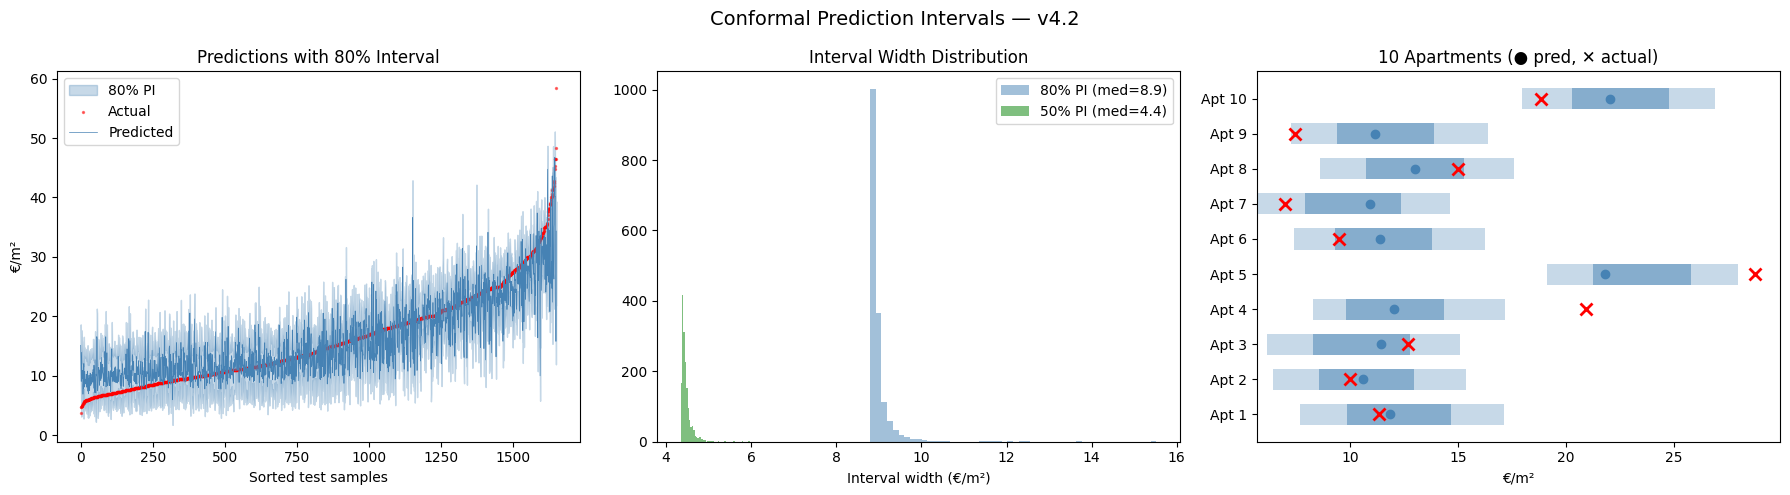

In [5]:
# Visualization
pi_80 = intervals[0.8]  # shape (n, 2)
pi_50 = intervals[0.5]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Sorted predictions with 80% PI band
ax = axes[0]
order = np.argsort(y_test.values)
ax.fill_between(range(len(order)), pi_80[order, 0], pi_80[order, 1],
                alpha=0.3, color='steelblue', label='80% PI')
ax.scatter(range(len(order)), y_test.values[order], s=2, alpha=0.5, c='red', label='Actual')
ax.plot(range(len(order)), y_pred[order], linewidth=0.5, c='steelblue', label='Predicted')
ax.set_title('Predictions with 80% Interval')
ax.set_xlabel('Sorted test samples')
ax.set_ylabel('€/m²')
ax.legend()

# 2. Interval width distribution
ax = axes[1]
widths_80 = pi_80[:, 1] - pi_80[:, 0]
widths_50 = pi_50[:, 1] - pi_50[:, 0]
ax.hist(widths_80, bins=50, alpha=0.5, label=f'80% PI (med={np.median(widths_80):.1f})', color='steelblue')
ax.hist(widths_50, bins=50, alpha=0.5, label=f'50% PI (med={np.median(widths_50):.1f})', color='green')
ax.set_title('Interval Width Distribution')
ax.set_xlabel('Interval width (€/m²)')
ax.legend()

# 3. 10 sample apartments with intervals
ax = axes[2]
sample_idx = np.random.RandomState(42).choice(len(y_test), 10, replace=False)
for i, idx in enumerate(sample_idx):
    actual = y_test.values[idx]
    pred = y_pred[idx]
    
    ax.barh(i, pi_80[idx, 1] - pi_80[idx, 0], left=pi_80[idx, 0],
            height=0.6, color='steelblue', alpha=0.3)
    ax.barh(i, pi_50[idx, 1] - pi_50[idx, 0], left=pi_50[idx, 0],
            height=0.6, color='steelblue', alpha=0.5)
    ax.plot(pred, i, 'o', color='steelblue', markersize=6)
    ax.plot(actual, i, 'x', color='red', markersize=8, markeredgewidth=2)

ax.set_yticks(range(10))
ax.set_yticklabels([f'Apt {i+1}' for i in range(10)])
ax.set_xlabel('€/m²')
ax.set_title('10 Apartments (● pred, ✕ actual)')

plt.suptitle('Conformal Prediction Intervals — v4.2', fontsize=14)
plt.tight_layout()
plt.show()

## Save MAPIE Model for Backend Deployment

In [6]:
# Save MAPIE regressor for backend
mapie_path = MODEL_DIR / 'mapie_regressor_v4.joblib'
joblib.dump(mapie_80, mapie_path)
size_mb = mapie_path.stat().st_size / 1e6

print(f'Saved: {mapie_path.name} ({size_mb:.1f} MB)')

# Example API response
idx = 0
pred = y_pred[idx]
low80, high80 = pi_80[idx, 0], pi_80[idx, 1]
low50, high50 = pi_50[idx, 0], pi_50[idx, 1]
sqm = 75  # example

print(f'\n=== Example API Response ===')
print(f'  predicted_rent_sqm: {pred:.2f}')
print(f'  interval_80: [{low80:.2f}, {high80:.2f}]')
print(f'  interval_50: [{low50:.2f}, {high50:.2f}]')
print(f'  monthly_range_80: [€{low80*sqm:.0f}, €{high80*sqm:.0f}]')
print(f'  interval_width_80: €{high80-low80:.2f}/m²')

print(f'\n=== Summary ===')
widths = pi_80[:, 1] - pi_80[:, 0]
print(f'  Median 80% interval width: €{np.median(widths):.2f}/m²')
print(f'  For a 75m² apartment: ±€{np.median(widths)*75/2:.0f}/month')
print(f'\n  Next: Update ml_service.py to load MAPIE and return intervals')

Saved: mapie_regressor_v4.joblib (8.9 MB)

=== Example API Response ===
  predicted_rent_sqm: 23.72
  interval_80: [18.79, 28.00]
  interval_50: [21.58, 26.03]
  monthly_range_80: [€1410, €2100]
  interval_width_80: €9.21/m²

=== Summary ===
  Median 80% interval width: €8.89/m²
  For a 75m² apartment: ±€334/month

  Next: Update ml_service.py to load MAPIE and return intervals
